# Capacity Sensitivity Tests via CLI Scripts

This notebook runs inference/evaluation scenarios by calling project scripts and then presents the generated metrics.

In [3]:
from __future__ import annotations

import json
import shlex
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display


def resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "pipeline_config.json").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing config/pipeline_config.json")


project_root = resolve_project_root(Path.cwd().resolve())
python_exe = Path(sys.executable)

print(f"Project root: {project_root}")
print(f"Python executable: {python_exe}")

Project root: C:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-cereals-neuroevolutivo-reduccion-ambiental-residuos
Python executable: c:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-cereals-neuroevolutivo-reduccion-ambiental-residuos\.venv\Scripts\python.exe


## Scenario Setup

Each scenario calls:
1. `scripts.run_inference`
2. `scripts.evaluate_inference`

Only capacity values change across scenarios.

In [6]:
base_capacities = {
    "cap_animal_feed": 120.0,
    "cap_composting": 140.0,
    "cap_biochar": 45.0,
    "cap_biomass_combustion": 10000.0,
}

sweep_values = {
    "cap_animal_feed": [80.0, 90.0, 100.0, 110.0, 120.0],
    "cap_composting": [100.0, 120.0, 140.0, 160.0, 180.0],
    "cap_biochar": [15.0, 30.0, 45.0, 60.0, 75.0],
}

scenarios = [{
    "name": "base",
    **base_capacities,
    "scenario_group": "reference",
    "varied_parameter": "none",
    "parameter_value": base_capacities["cap_animal_feed"],
}]

for parameter_name, values in sweep_values.items():
    for value in values:
        scenario = {
            "name": f"{parameter_name}_{int(value)}",
            **base_capacities,
            "scenario_group": f"sweep_{parameter_name}",
            "varied_parameter": parameter_name,
            "parameter_value": value,
        }
        scenario[parameter_name] = value
        scenarios.append(scenario)

seen = set()
unique_scenarios = []
for scenario in scenarios:
    key = (
        scenario["scenario_group"],
        scenario["parameter_value"],
        scenario["cap_animal_feed"],
        scenario["cap_composting"],
        scenario["cap_biochar"],
    )
    if key in seen:
        continue
    seen.add(key)
    unique_scenarios.append(scenario)

scenarios = unique_scenarios

dataset_path = "data/split/dataset_optimization_cereal_co2_test_raw.csv"
model_path = "models/artifacts/winner_genome.pkl"
neat_config_path = "config/config-feedforward.txt"
lots_per_day = 15
log_level = "INFO"
results_subdir = "capacity_sensitivity"
prediction_dir = project_root / "data/predictions" / results_subdir
metrics_dir = project_root / "models/metrics" / results_subdir
prediction_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

display(pd.DataFrame(scenarios)[[
    "name",
    "scenario_group",
    "varied_parameter",
    "parameter_value",
    "cap_animal_feed",
    "cap_composting",
    "cap_biochar",
]])

,name,scenario_group,varied_parameter,parameter_value,cap_animal_feed,cap_composting,cap_biochar
0,base,reference,none,120.0,120.0,140.0,45.0
1,cap_animal_feed_80,sweep_cap_animal_feed,cap_animal_feed,80.0,80.0,140.0,45.0
2,cap_animal_feed_90,sweep_cap_animal_feed,cap_animal_feed,90.0,90.0,140.0,45.0
3,cap_animal_feed_100,sweep_cap_animal_feed,cap_animal_feed,100.0,100.0,140.0,45.0
4,cap_animal_feed_110,sweep_cap_animal_feed,cap_animal_feed,110.0,110.0,140.0,45.0
5,cap_animal_feed_120,sweep_cap_animal_feed,cap_animal_feed,120.0,120.0,140.0,45.0
6,cap_composting_100,sweep_cap_composting,cap_composting,100.0,120.0,100.0,45.0
7,cap_composting_120,sweep_cap_composting,cap_composting,120.0,120.0,120.0,45.0
8,cap_composting_140,sweep_cap_composting,cap_composting,140.0,120.0,140.0,45.0
9,cap_composting_160,sweep_cap_composting,cap_composting,160.0,120.0,160.0,45.0


In [9]:
def run_command(args: list[str], cwd: Path) -> subprocess.CompletedProcess:

    completed = subprocess.run(
        args,
        cwd=str(cwd),
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.stdout:
        print(completed.stdout.strip())
    if completed.stderr:
        print(completed.stderr.strip())
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed with code {completed.returncode}: {printable}")
    return completed


records = []
for scenario in scenarios:
    name = scenario["name"]
    output_csv = f"data/predictions/{results_subdir}/inference_{name}.csv"
    output_report = f"models/metrics/{results_subdir}/inference_{name}_report.json"

    inference_cmd = [
        str(python_exe),
        "-m",
        "scripts.run_inference",
        "--project-root",
        ".",
        "--dataset-path",
        dataset_path,
        "--output-path",
        output_csv,
        "--model-path",
        model_path,
        "--neat-config-path",
        neat_config_path,
        "--lots-per-day",
        str(lots_per_day),
        "--cap-animal-feed",
        str(scenario["cap_animal_feed"]),
        "--cap-composting",
        str(scenario["cap_composting"]),
        "--cap-biochar",
        str(scenario["cap_biochar"]),
        "--cap-biomass-combustion",
        str(scenario["cap_biomass_combustion"]),
        "--log-level",
        log_level,
    ]

    evaluate_cmd = [
        str(python_exe),
        "-m",
        "scripts.evaluate_inference",
        "--project-root",
        ".",
        "--input-path",
        output_csv,
        "--report-path",
        output_report,
        "--log-level",
        log_level,
    ]

    run_command(inference_cmd, cwd=project_root)
    run_command(evaluate_cmd, cwd=project_root)

    report_path = project_root / output_report
    report = json.loads(report_path.read_text(encoding="utf-8"))

    records.append({
        "scenario": name,
        "scenario_group": scenario["scenario_group"],
        "varied_parameter": scenario["varied_parameter"],
        "parameter_value": scenario["parameter_value"],
        "cap_animal_feed": scenario["cap_animal_feed"],
        "cap_composting": scenario["cap_composting"],
        "cap_biochar": scenario["cap_biochar"],
        "cap_biomass_combustion": scenario["cap_biomass_combustion"],
        "baseline_total_emissions_kg": report["baseline_total_emissions_kg"],
        "ai_estimated_total_emissions_kg": report["ai_estimated_total_emissions_kg"],
        "total_emissions_reduction_pct": report["total_emissions_reduction_pct"],
        "mean_emissions_reduction_pct": report["mean_emissions_reduction_pct"],
        "ai_distribution": report["distribution_ai_pct_normalized"],
    })

results_df = pd.DataFrame(records).sort_values(["scenario_group", "parameter_value"], ascending=[True, True])
display(results_df[[
    "scenario",
    "scenario_group",
    "parameter_value",
    "cap_animal_feed",
    "cap_composting",
    "cap_biochar",
    "cap_biomass_combustion",
    "baseline_total_emissions_kg",
    "ai_estimated_total_emissions_kg",
    "total_emissions_reduction_pct",
    "mean_emissions_reduction_pct",
]])

2026-04-26 10:00:40,091 | INFO | optimization | Loading dataset from C:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-cereals-neuroevolutivo-reduccion-ambiental-residuos\data\split\dataset_optimization_cereal_co2_test_raw.csv
2026-04-26 10:00:40,102 | INFO | optimization | Loading preprocessing scaler from C:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-cereals-neuroevolutivo-reduccion-ambiental-residuos\data\split\dataset_optimization_cereal_co2_scaler.joblib
2026-04-26 10:00:40,616 | INFO | optimization | Loading winner genome from C:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-cereals-neuroevolutivo-reduccion-ambiental-residuos\models\artifacts\winner_genome.pkl
2026-04-26 10:00:40,616 | INFO | optimization | Loading NEAT config from C:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-cereals-neuroevolutivo-reduccion-ambiental-residuos\config\config-feedforward.txt
2026-04-26 10:00:40,824 | INFO | optimization | Inference finished. Output saved to C:\Users\IA\Desktop\Proyectos\DATAGIA\a33-cnp-c

,scenario,scenario_group,parameter_value,cap_animal_feed,cap_composting,cap_biochar,cap_biomass_combustion,baseline_total_emissions_kg,ai_estimated_total_emissions_kg,total_emissions_reduction_pct,mean_emissions_reduction_pct
0,base,reference,120.0,120.0,140.0,45.0,10000.0,42548061.68,30318135.65,28.74,28.74
1,cap_animal_feed_80,sweep_cap_animal_feed,80.0,80.0,140.0,45.0,10000.0,42548061.68,40107728.29,5.74,5.74
2,cap_animal_feed_90,sweep_cap_animal_feed,90.0,90.0,140.0,45.0,10000.0,42548061.68,37489636.18,11.89,11.89
3,cap_animal_feed_100,sweep_cap_animal_feed,100.0,100.0,140.0,45.0,10000.0,42548061.68,35143260.08,17.40,17.40
4,cap_animal_feed_110,sweep_cap_animal_feed,110.0,110.0,140.0,45.0,10000.0,42548061.68,32630218.76,23.31,23.31
5,cap_animal_feed_120,sweep_cap_animal_feed,120.0,120.0,140.0,45.0,10000.0,42548061.68,30318135.65,28.74,28.74
11,cap_biochar_15,sweep_cap_biochar,15.0,120.0,140.0,15.0,10000.0,42548061.68,34744145.47,18.34,18.34
12,cap_biochar_30,sweep_cap_biochar,30.0,120.0,140.0,30.0,10000.0,42548061.68,32221247.71,24.27,24.27
13,cap_biochar_45,sweep_cap_biochar,45.0,120.0,140.0,45.0,10000.0,42548061.68,30318135.65,28.74,28.74
14,cap_biochar_60,sweep_cap_biochar,60.0,120.0,140.0,60.0,10000.0,42548061.68,28171537.58,33.79,33.79


## Parameter Evolution vs Emissions Reduction

This section quantifies how capacity parameters move against emission reduction and visualizes the relationship.

What is plotted:
1. Capacity profiles vs reduction percentage by scenario.
2. Direct relationship between each capacity parameter and reduction.
3. Normalized evolution (index=1.0 at base scenario) for capacities and emission KPIs.

,scenario,scenario_group,varied_parameter,parameter_value,cap_animal_feed,cap_composting,cap_biochar,cap_non_biomass_total,total_emissions_reduction_pct,mean_emissions_reduction_pct,ai_estimated_total_emissions_kg
0,base,reference,none,120.0,120.0,140.0,45.0,305.0,28.74,28.74,30318135.65
1,cap_animal_feed_80,sweep_cap_animal_feed,cap_animal_feed,80.0,80.0,140.0,45.0,265.0,5.74,5.74,40107728.29
2,cap_animal_feed_90,sweep_cap_animal_feed,cap_animal_feed,90.0,90.0,140.0,45.0,275.0,11.89,11.89,37489636.18
3,cap_animal_feed_100,sweep_cap_animal_feed,cap_animal_feed,100.0,100.0,140.0,45.0,285.0,17.40,17.40,35143260.08
4,cap_animal_feed_110,sweep_cap_animal_feed,cap_animal_feed,110.0,110.0,140.0,45.0,295.0,23.31,23.31,32630218.76
5,cap_animal_feed_120,sweep_cap_animal_feed,cap_animal_feed,120.0,120.0,140.0,45.0,305.0,28.74,28.74,30318135.65
6,cap_biochar_15,sweep_cap_biochar,cap_biochar,15.0,120.0,140.0,15.0,275.0,18.34,18.34,34744145.47
7,cap_biochar_30,sweep_cap_biochar,cap_biochar,30.0,120.0,140.0,30.0,290.0,24.27,24.27,32221247.71
8,cap_biochar_45,sweep_cap_biochar,cap_biochar,45.0,120.0,140.0,45.0,305.0,28.74,28.74,30318135.65
9,cap_biochar_60,sweep_cap_biochar,cap_biochar,60.0,120.0,140.0,60.0,320.0,33.79,33.79,28171537.58


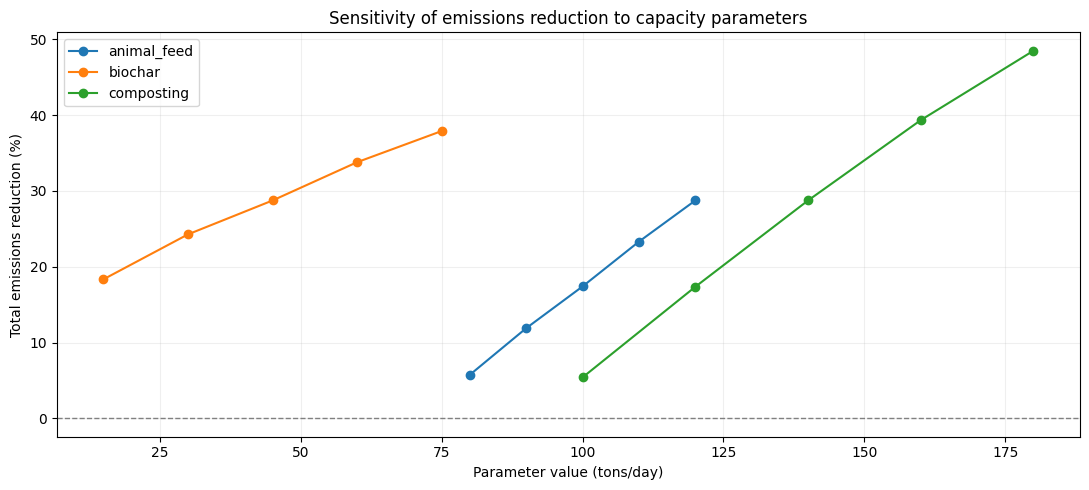

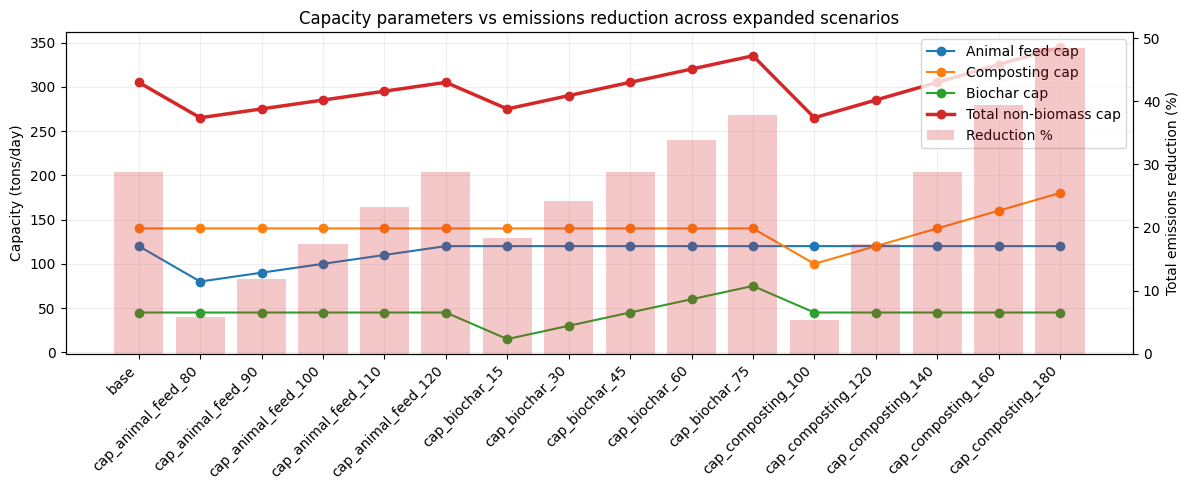

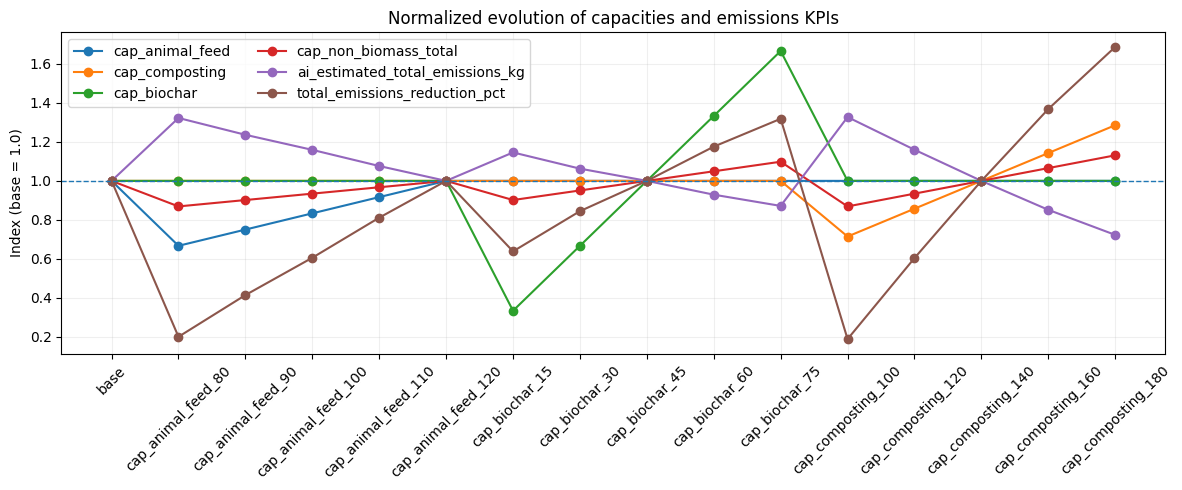

Correlation with total_emissions_reduction_pct
cap_non_biomass_total    0.9791
cap_composting           0.7381
cap_animal_feed          0.5849
cap_biochar              0.3319
Name: total_emissions_reduction_pct, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import numpy as np

analysis_df = results_df.copy()

numeric_cols = [
    "cap_animal_feed",
    "cap_composting",
    "cap_biochar",
    "cap_biomass_combustion",
    "baseline_total_emissions_kg",
    "ai_estimated_total_emissions_kg",
    "total_emissions_reduction_pct",
    "mean_emissions_reduction_pct",
    "parameter_value",
]
for col in numeric_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df["cap_non_biomass_total"] = (
    analysis_df["cap_animal_feed"]
    + analysis_df["cap_composting"]
    + analysis_df["cap_biochar"]
)

analysis_df = analysis_df.sort_values(["scenario_group", "parameter_value"]).reset_index(drop=True)
display(
    analysis_df[
        [
            "scenario",
            "scenario_group",
            "varied_parameter",
            "parameter_value",
            "cap_animal_feed",
            "cap_composting",
            "cap_biochar",
            "cap_non_biomass_total",
            "total_emissions_reduction_pct",
            "mean_emissions_reduction_pct",
            "ai_estimated_total_emissions_kg",
        ]
    ]
)

# 1) Reduction curve for each sweep parameter
fig, ax = plt.subplots(figsize=(11, 5))
for parameter_name, group in analysis_df[analysis_df["scenario_group"] != "reference"].groupby("varied_parameter"):
    group = group.sort_values("parameter_value")
    ax.plot(
        group["parameter_value"],
        group["total_emissions_reduction_pct"],
        marker="o",
        label=parameter_name.replace("cap_", ""),
    )

ax.axhline(0.0, linestyle="--", linewidth=1, color="gray")
ax.set_xlabel("Parameter value (tons/day)")
ax.set_ylabel("Total emissions reduction (%)")
ax.set_title("Sensitivity of emissions reduction to capacity parameters")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# 2) Capacity profile vs reduction, including reference scenario
reference_row = analysis_df.loc[analysis_df["scenario_group"] == "reference"].iloc[0]
comparison_df = analysis_df.copy()
comparison_df["distance_to_reference"] = (
    (comparison_df["cap_animal_feed"] - reference_row["cap_animal_feed"]).abs()
    + (comparison_df["cap_composting"] - reference_row["cap_composting"]).abs()
    + (comparison_df["cap_biochar"] - reference_row["cap_biochar"]).abs()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = np.arange(len(comparison_df))
labels = comparison_df["scenario"].tolist()

ax1.plot(x, comparison_df["cap_animal_feed"], marker="o", label="Animal feed cap")
ax1.plot(x, comparison_df["cap_composting"], marker="o", label="Composting cap")
ax1.plot(x, comparison_df["cap_biochar"], marker="o", label="Biochar cap")
ax1.plot(x, comparison_df["cap_non_biomass_total"], marker="o", linewidth=2.5, label="Total non-biomass cap")

ax2.bar(x, comparison_df["total_emissions_reduction_pct"], alpha=0.25, color="tab:red", label="Reduction %")

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.set_ylabel("Capacidad (t/día)")
ax2.set_ylabel("Reducción total de emisiones (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 3) Normalized evolution, with the base scenario as reference
ref_row = reference_row

evolution_cols = [
    "cap_animal_feed",
    "cap_composting",
    "cap_biochar",
    "cap_non_biomass_total",
    "ai_estimated_total_emissions_kg",
    "total_emissions_reduction_pct",
]

norm_df = comparison_df[["scenario", "scenario_group", "varied_parameter", "parameter_value", *evolution_cols]].copy()
for col in evolution_cols:
    ref_val = float(ref_row[col])
    norm_df[f"{col}_idx"] = norm_df[col] / ref_val if ref_val != 0 else np.nan

idx_cols = [f"{col}_idx" for col in evolution_cols]
idx_plot = norm_df[["scenario", "scenario_group", "varied_parameter", *idx_cols]].set_index("scenario")

fig, ax = plt.subplots(figsize=(12, 5))
for col in idx_cols:
    ax.plot(idx_plot.index, idx_plot[col], marker="o", label=col.replace("_idx", ""))

ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_ylabel("Index (base = 1.0)")
ax.set_title("Normalized evolution of capacities and emissions KPIs")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.2)
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

# Optional numeric summary for quick interpretation
corr = comparison_df[[
    "cap_animal_feed",
    "cap_composting",
    "cap_biochar",
    "cap_non_biomass_total",
    "total_emissions_reduction_pct",
]].corr(numeric_only=True)["total_emissions_reduction_pct"].drop("total_emissions_reduction_pct")

print("Correlation with total_emissions_reduction_pct")
print(corr.sort_values(ascending=False).round(4))